In [91]:
#import CSV file as DataFrame
import pandas as pd
df = pd.read_csv('indian_food.csv')

#view DataFrame


In [92]:
df

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East
...,...,...,...,...,...,...,...,...,...
250,Til Pitha,"Glutinous rice, black sesame seeds, gur",vegetarian,5,30,sweet,dessert,Assam,North East
251,Bebinca,"Coconut milk, egg yolks, clarified butter, all...",vegetarian,20,60,sweet,dessert,Goa,West
252,Shufta,"Cottage cheese, dry dates, dried rose petals, ...",vegetarian,-1,-1,sweet,dessert,Jammu & Kashmir,North
253,Mawa Bati,"Milk powder, dry fruits, arrowroot powder, all...",vegetarian,20,45,sweet,dessert,Madhya Pradesh,Central


In [93]:
# Replace both integer and string versions globally
import numpy as np

df = df.replace([-1, "-1"], np.nan)

In [94]:
df

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45.0,25.0,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80.0,30.0,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15.0,60.0,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15.0,30.0,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15.0,40.0,sweet,dessert,West Bengal,East
...,...,...,...,...,...,...,...,...,...
250,Til Pitha,"Glutinous rice, black sesame seeds, gur",vegetarian,5.0,30.0,sweet,dessert,Assam,North East
251,Bebinca,"Coconut milk, egg yolks, clarified butter, all...",vegetarian,20.0,60.0,sweet,dessert,Goa,West
252,Shufta,"Cottage cheese, dry dates, dried rose petals, ...",vegetarian,NaN,NaN,sweet,dessert,Jammu & Kashmir,North
253,Mawa Bati,"Milk powder, dry fruits, arrowroot powder, all...",vegetarian,20.0,45.0,sweet,dessert,Madhya Pradesh,Central


In [95]:
# Get the number of rows
rows = df.shape[0]
print(f"Number of rows: {rows}")

# Get the number of columns
columns = df.shape[1]
print(f"Number of columns: {columns}")

Number of rows: 255
Number of columns: 9


In [96]:
mean_preptime = df['prep_time'].mean()
std_preptime = df['prep_time'].std()
var_preptime = df['prep_time'].var()
freq_preptime = df['prep_time'].value_counts()

mean_cooktime = df['cook_time'].mean()
std_cooktime = df['cook_time'].std()
var_cooktime = df['cook_time'].var()
freq_cooktime = df['cook_time'].value_counts()

print("Average prep time =", mean_preptime)
print("Prep time standard deviation =", std_preptime)
print("Prep time variance =", var_preptime)
print("Frequency,", freq_preptime)

print("Average cook time =", mean_cooktime)
print("Cook time standard deviation =", std_cooktime)
print("Cook time variance =", var_cooktime)
print("Frequency,", freq_cooktime)

Average prep time = 35.38666666666666
Prep time standard deviation = 76.24108144563533
Prep time variance = 5812.7025
Frequency, prep_time
10.0     98
20.0     40
15.0     22
5.0      16
30.0     12
45.0      5
120.0     5
25.0      5
240.0     4
40.0      3
360.0     3
60.0      2
180.0     2
80.0      1
500.0     1
150.0     1
480.0     1
495.0     1
70.0      1
35.0      1
12.0      1
Name: count, dtype: int64
Average cook time = 38.91189427312775
Cook time standard deviation = 49.42171058724396
Cook time variance = 2442.5054773693014
Frequency, cook_time
30.0     59
20.0     42
40.0     27
60.0     22
45.0     15
25.0     13
50.0     10
35.0      9
90.0      7
10.0      7
15.0      5
120.0     3
5.0       3
75.0      1
720.0     1
55.0      1
2.0       1
6.0       1
Name: count, dtype: int64


In [97]:
avg_preptime_diet = df.groupby('diet')['prep_time'].mean()
print("Average prep time", avg_preptime_diet)

Average prep time diet
non vegetarian    41.842105
vegetarian        34.791262
Name: prep_time, dtype: float64


In [98]:
avg_cooktime_diet = df.groupby('diet')['cook_time'].mean()
print(avg_cooktime_diet)

diet
non vegetarian    40.0000
vegetarian        38.8125
Name: cook_time, dtype: float64


In [99]:
avg_preptime_course = df.groupby('course')['prep_time'].mean()
print(avg_preptime_course)

course
dessert         29.961039
main course     29.681818
snack           56.388889
starter        180.000000
Name: prep_time, dtype: float64


In [100]:
avg_cooktime_course = df.groupby('course')['cook_time'].mean()
print(avg_cooktime_course)

course
dessert        47.341772
main course    35.272727
snack          31.611111
starter        37.500000
Name: cook_time, dtype: float64


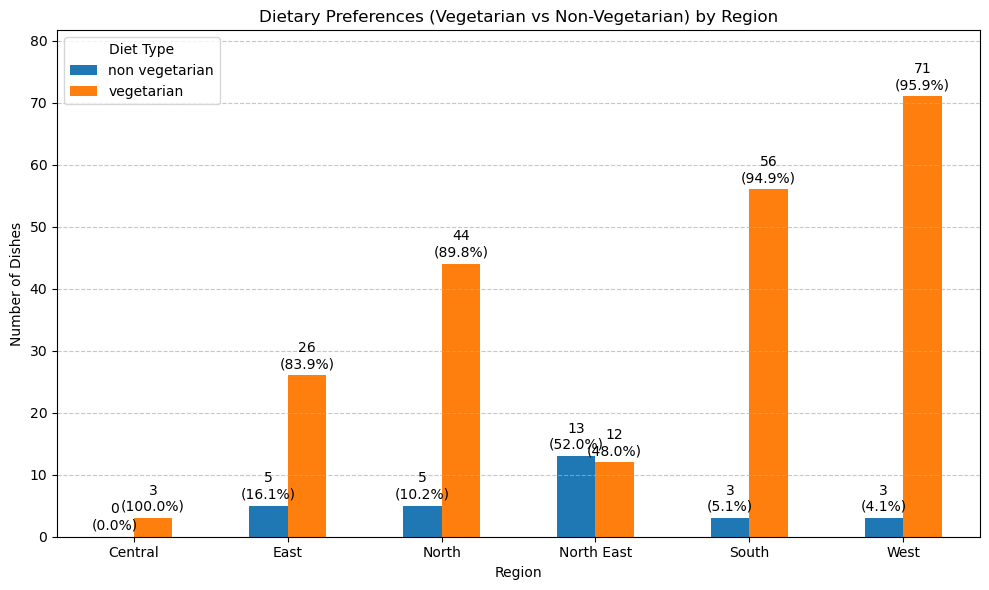

In [101]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your crosstab is generated like this:
diet_counts = pd.crosstab(df['region'], df['diet'])

# 1. Calculate the ratios/percentages for each category
# This divides each bar's value by the total of its row (total dishes in that region)
diet_pcts = diet_counts.div(diet_counts.sum(axis=1), axis=0) * 100

# 2. Plot the bar graph
ax = diet_counts.plot(kind='bar', figsize=(10, 6), rot=0)

# 3. Add Custom Labels (Showing both the count and the percentage)
# Iterate through each bar container
for container in ax.containers:
    # Get the column name (e.g., 'Vegetarian', 'Non-Vegetarian') for the legend
    col_name = container.get_label()
    
    # Create a list of custom labels formatted as: "Count\n(Percentage%)"
    labels = [
        f'{count:.0f}\n({pct:.1f}%)' 
        for count, pct in zip(container.datavalues, diet_pcts[col_name])
    ]
    
    # Apply the labels to the bars
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

# 4. Customize the chart
plt.title('Dietary Preferences (Vegetarian vs Non-Vegetarian) by Region')
plt.xlabel('Region')
plt.ylabel('Number of Dishes')
plt.legend(title='Diet Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-limit to ensure the top labels don't get cut off
plt.ylim(0, diet_counts.max().max() * 1.15) 

# Display the plot
plt.tight_layout()
plt.show()


**This graph shows the number and ratio of vegetarian vs non-vegetarian dishes, popular in each of six regions of India**

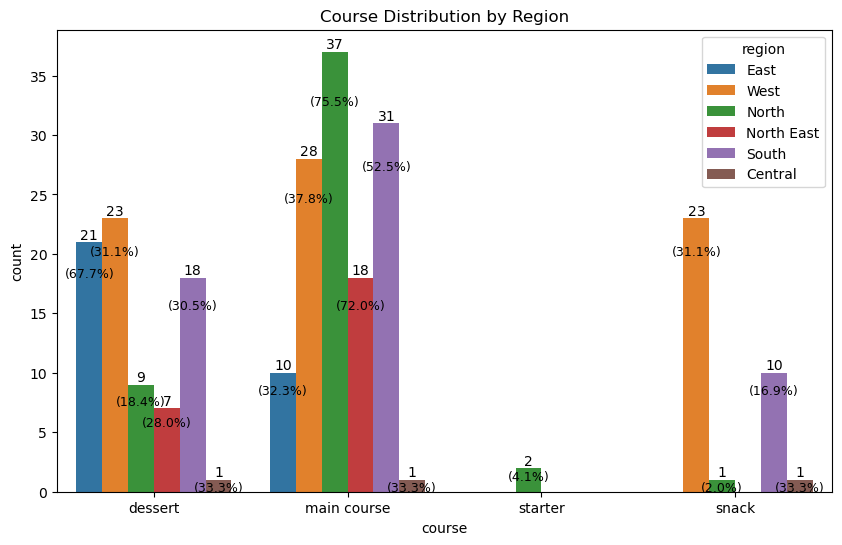

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the total count for each region to compute ratios
region_totals = df["region"].value_counts()

plt.figure(figsize=(10, 6))
# Create the countplot (ensure x is 'course' and hue is 'region')
ax = sns.countplot(data=df, x="course", hue="region")

# 1. Add the actual count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container)

# 2. Add the ratio labels below the actual counts
# ax.containers holds the bars grouped by 'hue' (region)
# The order of containers matches the order of unique regions in the plot
regions_order = (
    df["region"].unique()
    if ax.get_legend() is None
    else [t.get_text() for t in ax.get_legend().get_texts()]
)

for container, region in zip(ax.containers, regions_order):
    total_for_region = region_totals[region]
    

    for bar in container:
        height = bar.get_height()
        if height > 0:  # Skip bars with zero count
            # Calculate percentage based on the region's total
            percentage = f"({(height / total_for_region) * 100:.1f}%)"
            

            # Get coordinates for the label
            x_pos = bar.get_x() + bar.get_width() / 2
            # Position it slightly below the top of the bar / count label
            y_pos = height - (height * 0.1)

            ax.text(
                x_pos,
                y_pos,
                percentage,
                ha="center",
                va="top",
                fontsize=9,
                color="black",
            )

plt.title("Course Distribution by Region")
plt.show()


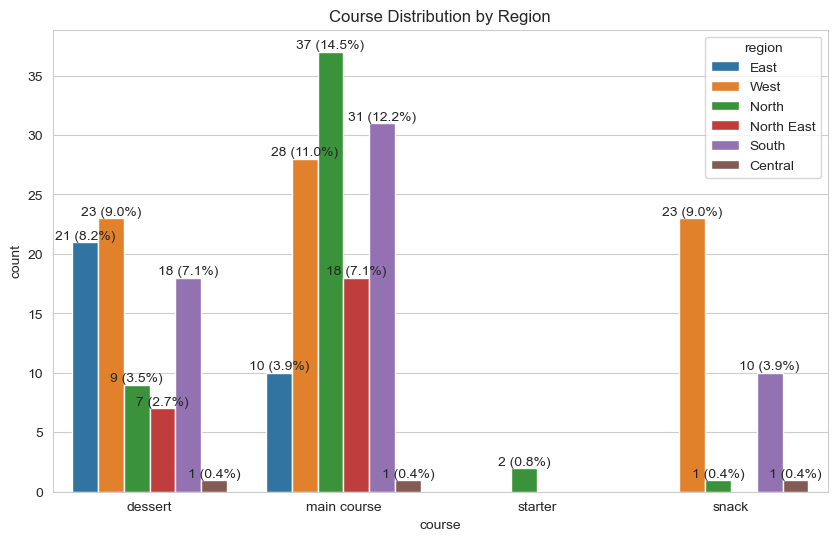

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate total count for percentages
total_courses = len(df)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='course', hue='region')

# Loop through containers to add count and percentage labels
for container in ax.containers:
    # Calculate percentage for each bar dynamically
    labels = [f'{v.get_height():.0f} ({v.get_height()/total_courses:.1%})' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels)

plt.title('Course Distribution by Region')
plt.show()

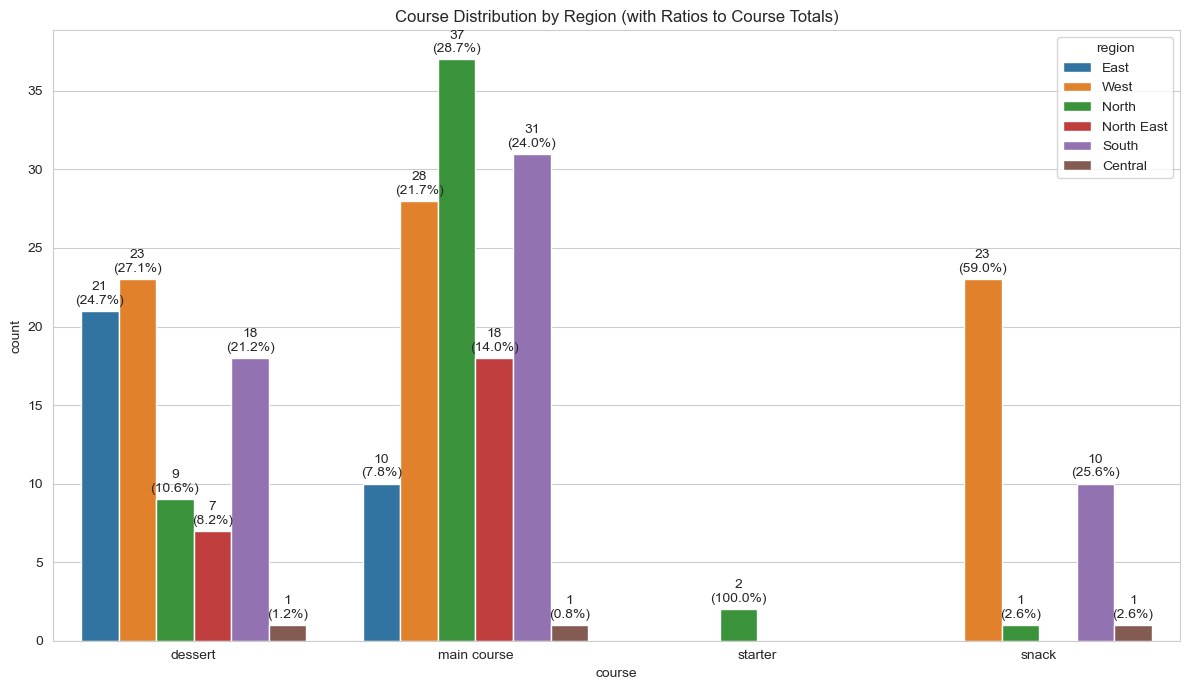

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the total count for each course to use as the denominator
course_totals = df["course"].value_counts()

plt.figure(figsize=(12, 7))
ax = sns.countplot(data=df, x="course", hue="region")

# 2. Loop through containers to calculate and add custom labels
for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()

        # Handle potential NaN or zero values for empty bars
        if height > 0:
            # Get the course name from the x-axis tick position
            x_pos = bar.get_x() + bar.get_width() / 2
            tick_idx = int(x_pos + 0.5)
            course_name = ax.get_xticklabels()[tick_idx].get_text()

            # Calculate ratio and percentage
            total = course_totals[course_name]
            percentage = (height / total) * 100

            # Format label showing: Count (Percentage%)
            labels.append(f"{int(height)}\n({percentage:.1f}%)")
        else:
            labels.append("")

    # Apply the custom labels to the bar container
    ax.bar_label(container, labels=labels, label_type="edge", padding=3)

plt.title("Course Distribution by Region (with Ratios to Course Totals)")
plt.tight_layout()
plt.show()


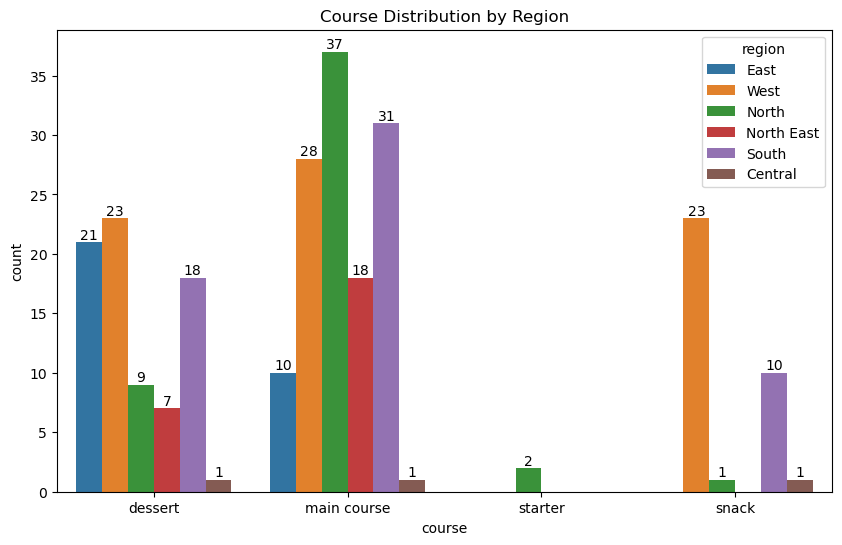

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='course', hue='region')

# 2. Loop through bar containers and add labels
for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Course Distribution by Region')
plt.show()

**Here you can see the distribution among 4 dish courses, typical to different regions of the country.**

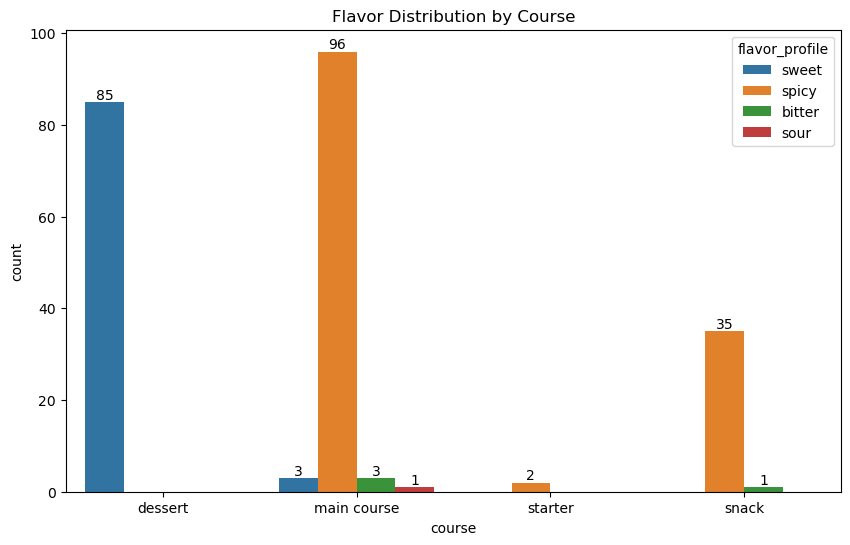

In [105]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='course', hue='flavor_profile')

# 2. Loop through bar containers and add labels
for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Flavor Distribution by Course')
plt.show()

**This is how different flavors are distributed by courses. All desserts are sweet (surprise!:), and a vast majority of main course dishes is spicy**

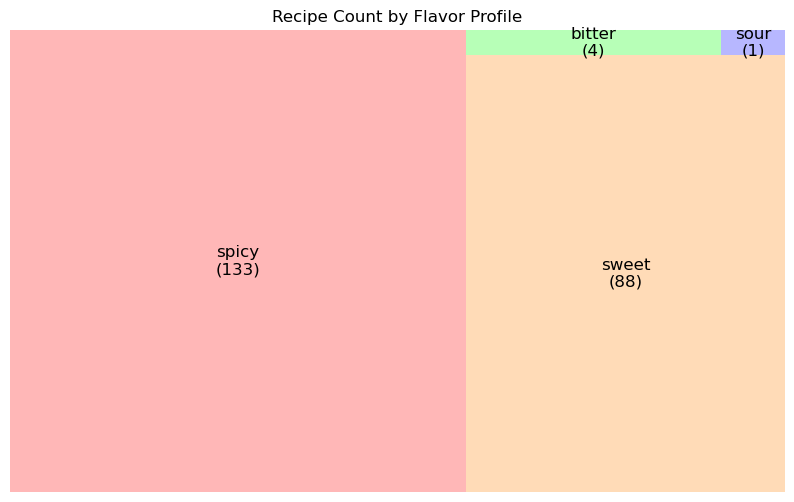

In [106]:
import squarify

# 2. Count the occurrences of each flavor_profile
flavor_counts = df['flavor_profile'].value_counts()

# 3. Prepare data for plotting
sizes = flavor_counts.values
labels = [f'{label}\n({count})' for label, count in zip(flavor_counts.index, flavor_counts.values)]
colors = ['#ff9999', '#ffcc99', '#99ff99', '#9999ff'] # Red, Orange, Green, Blue

# 4. Create the Treemap
plt.figure(figsize=(10, 6))
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.7, text_kwargs={'fontsize':12})
plt.title('Recipe Count by Flavor Profile')
plt.axis('off') # Hide axes
plt.show()


**Spicy is the winner of total count by flavor profile, with Sweet being a runner up.**

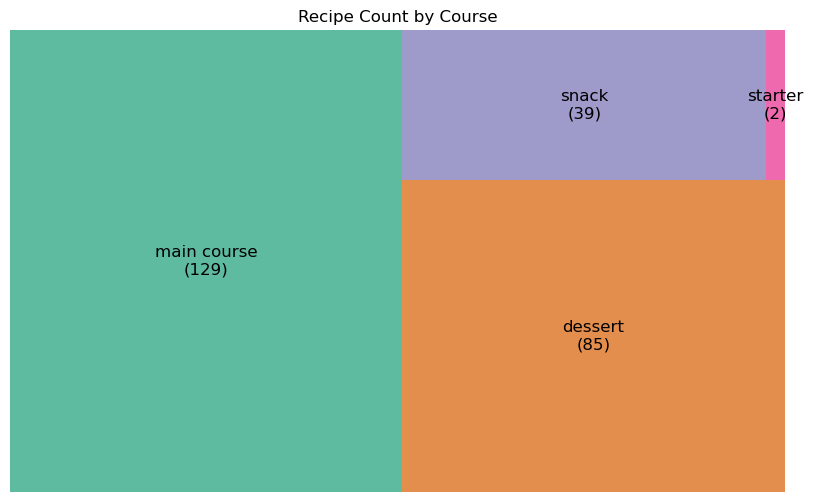

In [107]:
#import numpy as np
import matplotlib as mpl

# 2. Count the occurrences of each flavor_profile
course_counts = df['course'].value_counts()

# 3. Prepare data for plotting
sizes = course_counts.values
labels = [f'{label}\n({count})' for label, count in zip(course_counts.index, course_counts.values)]
#colors = ['#ff9999', '#ffcc99', '#99ff99', '#9999ff'] # Red, Orange, Green, Blue
colors = mpl.colormaps['Dark2'].colors

# 4. Create the Treemap
plt.figure(figsize=(10, 6))
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.7, text_kwargs={'fontsize':12})
plt.title('Recipe Count by Course')
plt.axis('off') # Hide axes
plt.show()

**Main course is what you mostly need. Then dessert!**

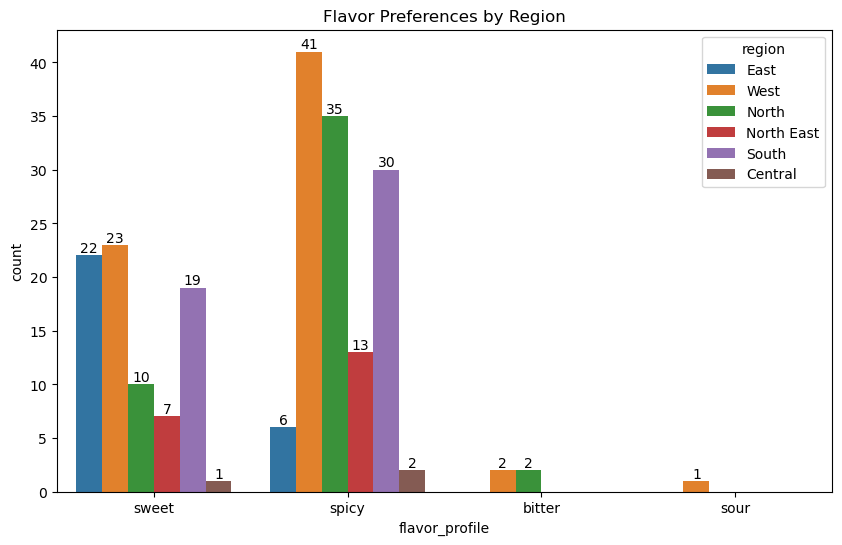

In [108]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='flavor_profile', hue='region')

# 2. Loop through bar containers and add labels
for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Flavor Preferences by Region')
plt.show()

**Some Like It Hot! In all regions.**

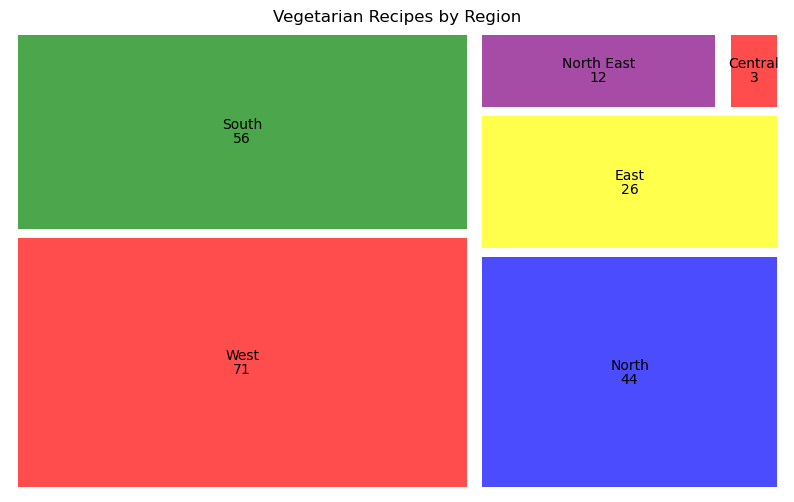

In [109]:
# 2. Filter for vegetarian recipes only
veg_recipes = df[df['diet'] == 'vegetarian']

# 3. Aggregate data: Count vegetarian recipes per region
region_counts = veg_recipes['region'].value_counts()

# 4. Create the Treemap using squarify
plt.figure(figsize=(10, 6))
squarify.plot(sizes=region_counts.values, 
              label=region_counts.index, 
              value=region_counts.values, 
              alpha=0.7, 
              pad=True,
              color=['red', 'green', 'blue', 'yellow', 'purple'])
plt.title('Vegetarian Recipes by Region')
plt.axis('off') # Hide axes
plt.show()

**Vegetarian dishes count among the regions.**

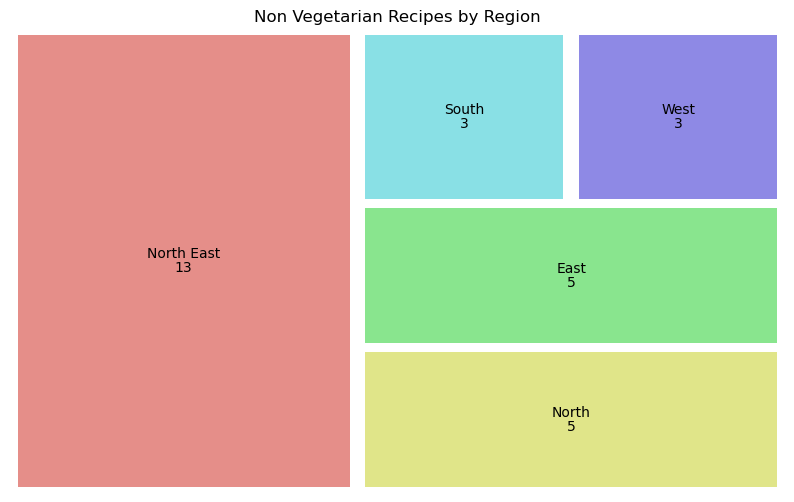

In [110]:

# 2. Filter for non vegetarian recipes only
nonveg_recipes = df[df['diet'] == 'non vegetarian']

# 3. Aggregate data: Count vegetarian recipes per region
region_counts = nonveg_recipes['region'].value_counts()

# 4. Create the Treemap using squarify
plt.figure(figsize=(10, 6))
squarify.plot(sizes=region_counts.values, 
              label=region_counts.index, 
              value=region_counts.values, 
              alpha=0.7, 
              pad=True,
              #color=['red', 'green', 'blue', 'yellow', 'purple'])
              color=sns.color_palette("hls"))
plt.title('Non Vegetarian Recipes by Region')
plt.axis('off') # Hide axes
plt.show()

**Non-vegetarian dishes count among the regions. Not a lot!**

In [111]:
# 2. Filter rows containing "sugar" (case-insensitive)
# Assumes ingredients are in a comma-separated string
sugar_recipes = df[df['ingredients'].str.contains('sugar', case=False, na=False)]

# 3. Group by region and count
sugar_counts = sugar_recipes.groupby('region')['name'].count()

# 4.Count the number of recipes for each region
region_counts = df['region'].value_counts()

print(region_counts)

print("Sugar recipes count by region:")
print(sugar_counts)

print(sugar_counts/region_counts)

region
West          74
South         59
North         49
East          31
North East    25
Central        3
Name: count, dtype: int64
Sugar recipes count by region:
region
East          16
North          4
North East     3
South         10
West          15
Name: name, dtype: int64
region
Central            NaN
East          0.516129
North         0.081633
North East    0.120000
South         0.169492
West          0.202703
dtype: float64


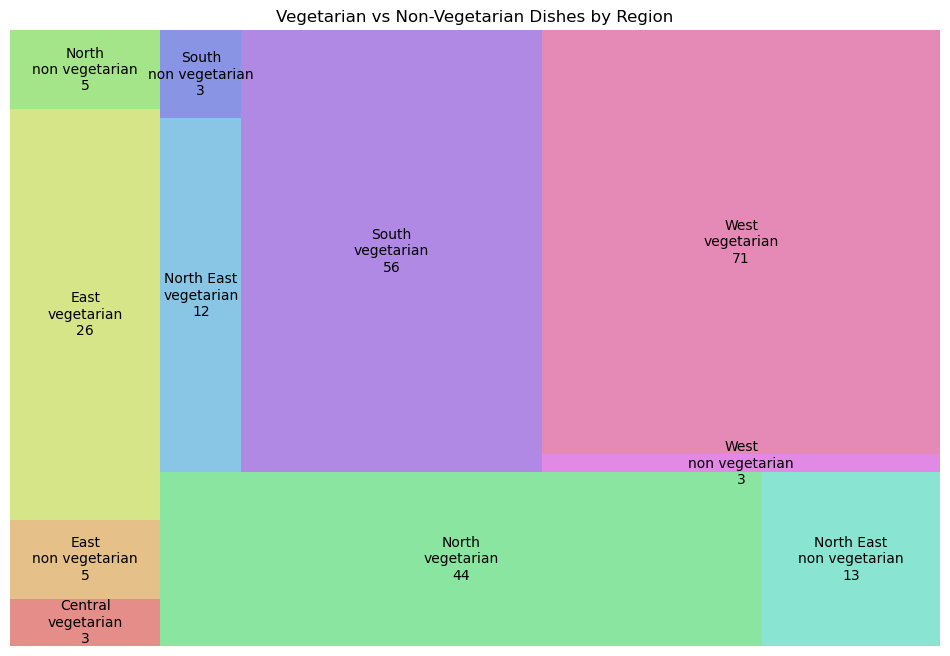

In [112]:
# 2. Clean Data (Handle NaN)
df['diet'] = df['diet'].fillna('Unknown')
grouped = df.groupby(['region', 'diet']).size().reset_index(name='Count')
grouped['Label'] = grouped['region'] + "\n" + grouped['diet'] + "\n" + grouped['Count'].astype(str)

# 3. Plotting
plt.figure(figsize=(12, 8))

colors = sns.color_palette("hls", len(grouped))
#colors = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3'] # Define custom colors
squarify.plot(sizes=grouped['Count'], label=grouped['Label'], color=colors, alpha=0.7)
plt.axis('off')
plt.title("Vegetarian vs Non-Vegetarian Dishes by Region")
plt.show()


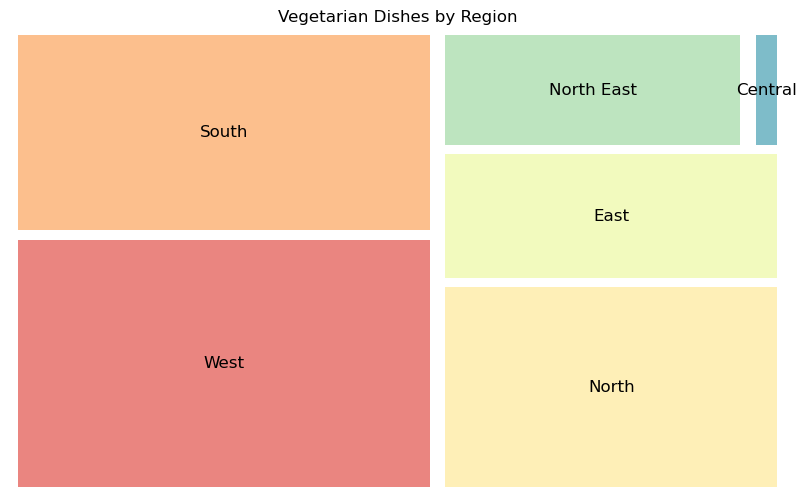

In [113]:
import numpy as np
import matplotlib as mpl
import seaborn as sns


import squarify    # pip install squarify (algorithm for treemap)
# plot it

# 2. Filter and Clean Data
# Filter vegetarian only, drop rows with NaN in critical columns
#veg_df = df[df['diet'] == 'vegetarian'].dropna(subset=['region'])

# 2. Filter for Vegetarian and Aggregate by Region
veg_data = df[df['diet'] == 'vegetarian'].groupby('region').size().reset_index(name='Count')
veg_data = veg_data.sort_values(by='Count', ascending=False)

# 3. Aggregate data
region_counts = df['region'].value_counts()

colors = sns.color_palette("Spectral", len(veg_data))

formatted_labels = [f"{region}\n({count})" for region, count in zip(region_counts.index, region_counts.values)]
# 4. Create Treemap
plt.figure(figsize=(10, 6))
squarify.plot(sizes=region_counts.values, 
              label=region_counts.index, 
              alpha=0.7,
              pad=True,
              color=colors,
              text_kwargs={'fontsize':12})
plt.title('Vegetarian Dishes by Region')
plt.axis('off')
plt.show()

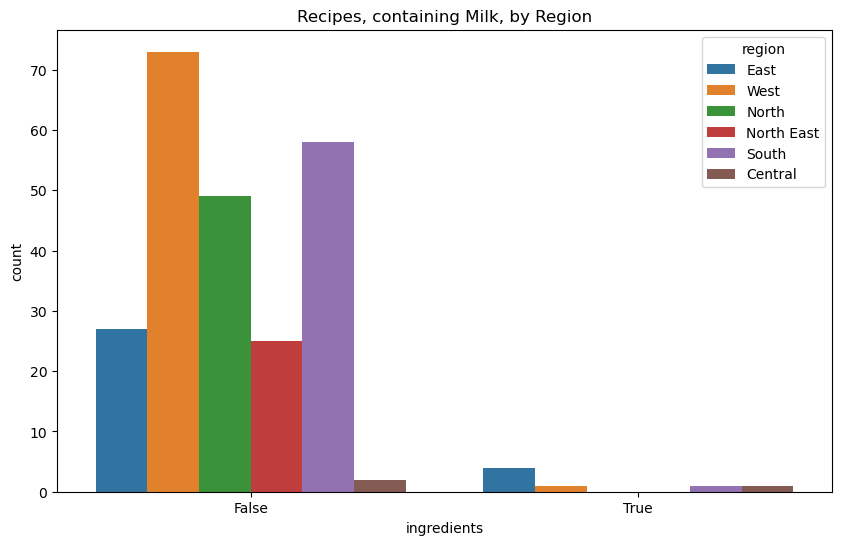

In [114]:
#sns.violinplot(x=df['ingredients'].str.contains('Milk' or 'milk'), y=df["region"])
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=df['ingredients'].str.contains('Milk' or 'milk'), hue='region')
plt.title('Recipes, containing Milk, by Region')
plt.show()

<Axes: xlabel='diet', ylabel='region'>

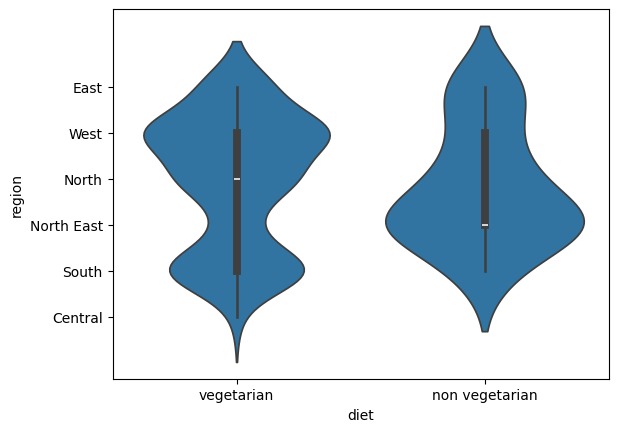

In [115]:
#import seaborn as sns
#df = sns.load_dataset('indian_food')

# plot
sns.violinplot(x=df["diet"], y=df["region"])

<Axes: xlabel='flavor_profile', ylabel='region'>

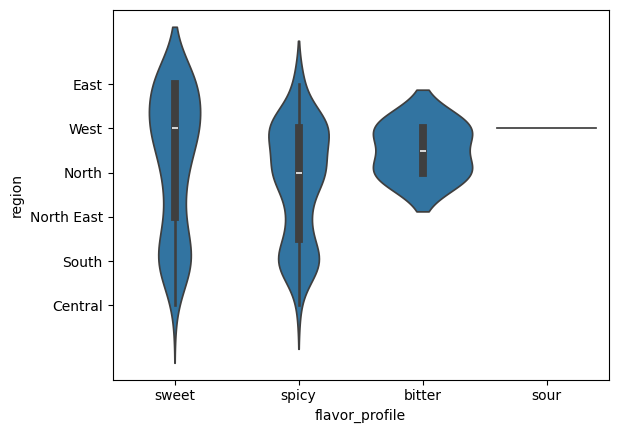

In [116]:
sns.violinplot(x=df["flavor_profile"], y=df["region"])

<Axes: xlabel='diet', ylabel='state'>

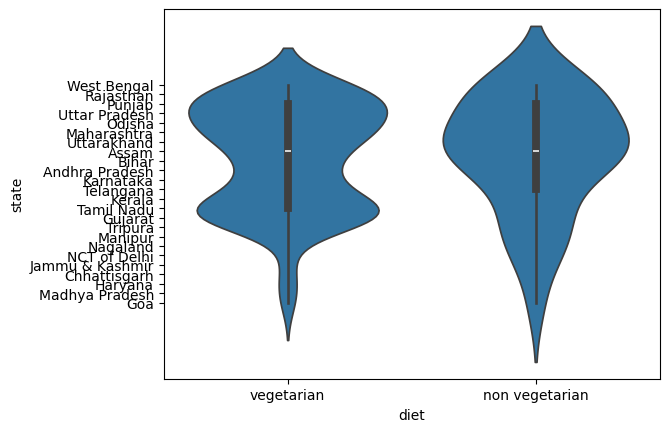

In [117]:
sns.violinplot(x=df["diet"], y=df["state"])

<Axes: xlabel='course', ylabel='region'>

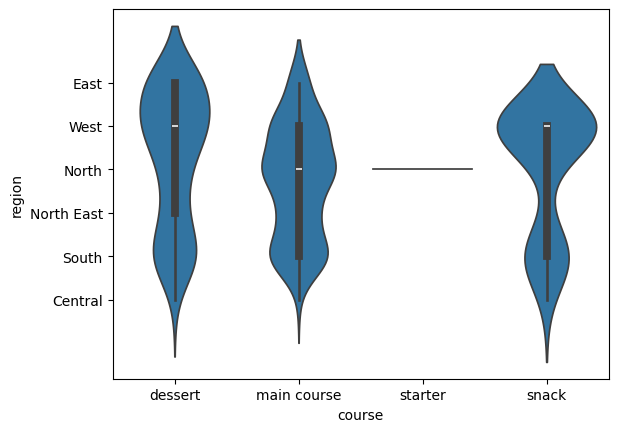

In [118]:
sns.violinplot(x=df["course"], y=df["region"])

In [119]:
#import numpy as np
filtered_df = df[df['ingredients'].str.contains('Milk' or 'milk', case=False, na=False)]['name']

# View the filtered DataFrame
print(filtered_df)

2           Gajar ka halwa
3                   Ghevar
4              Gulab jamun
8                 Kalakand
9                    Kheer
11                   Lassi
15                   Rabri
16                  Sheera
19             Sohan papdi
21           Chhena kheeri
24             Kheer sagar
26                Lyangcha
29               Misti doi
32                Rasabali
33               Ras malai
35                 Sandesh
40           Dharwad pedha
41        Double ka meetha
45              Mysore pak
47           Palathalikalu
52             Sheer korma
56                 Basundi
58                Doodhpak
66          Chak Hao Kheer
103         Mushroom matar
120            Shahi tukra
148             Paravannam
149                Payasam
170           Coconut vadi
176             Copra paak
187               Halvasan
232    Chingri malai curry
247      Prawn malai curry
251                Bebinca
253              Mawa Bati
Name: name, dtype: object


<Axes: xlabel='ingredients', ylabel='region'>

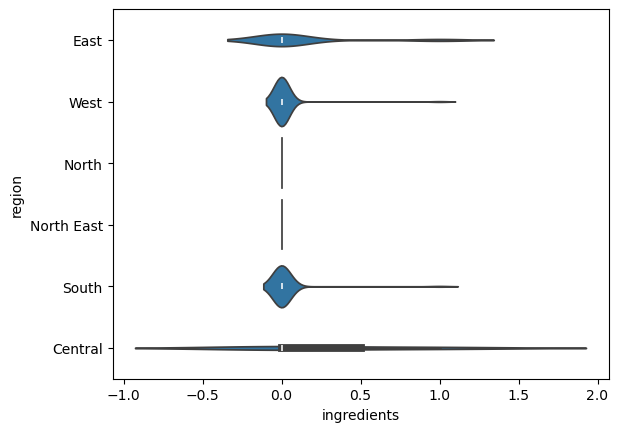

In [120]:
sns.violinplot(x=df['ingredients'].str.contains('Milk' or 'milk'), y=df["region"])

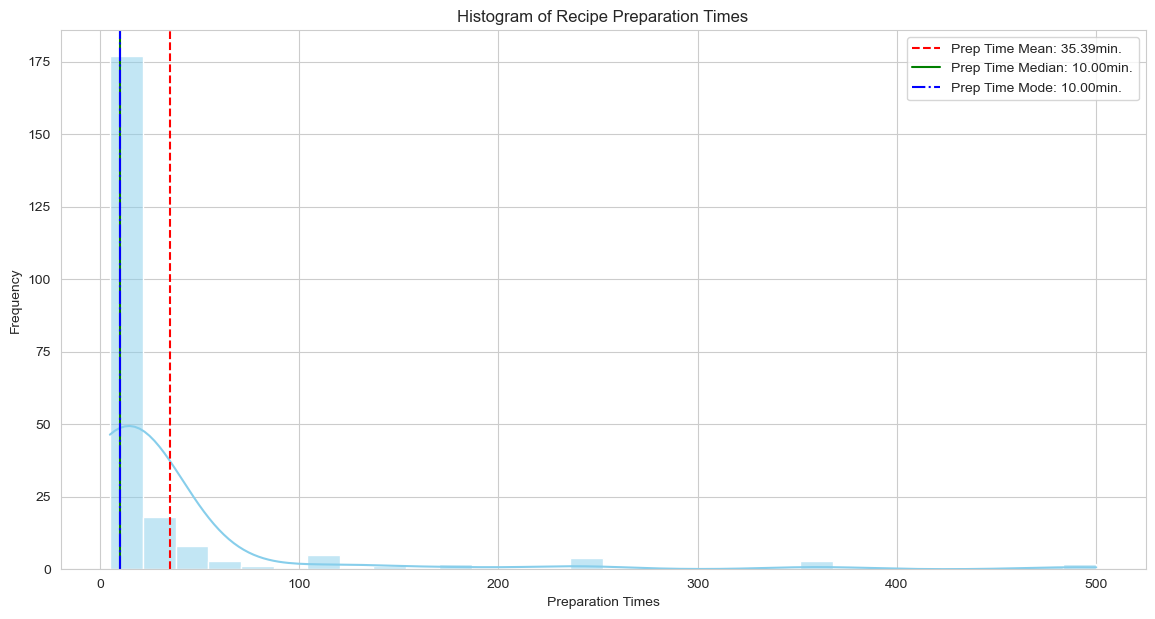

In [121]:
# Importing visualization libraries
import matplotlib.pyplot as plt
#import seaborn as sns

# Setting up the style
sns.set_style("whitegrid")

# Calculate Mean, Median, Mode for Prep time

median_preptime = df['prep_time'].median()
mode_preptime = df['prep_time'].mode().values[0]

median_cooktime = df['cook_time'].median()
mode_cooktime = df['cook_time'].mode().values[0]


# Plotting the histogram
plt.figure(figsize=(14, 7))
sns.histplot(x=df['prep_time'], bins=30, kde=True, color="skyblue")


plt.axvline(mean_preptime, color='r', linestyle='--', label=f"Prep Time Mean: {mean_preptime:.2f}min.")
plt.axvline(median_preptime, color='g', linestyle='-', label=f"Prep Time Median: {median_preptime:.2f}min.")
plt.axvline(mode_preptime, color='b', linestyle='-.', label=f"Prep Time Mode: {mode_preptime:.2f}min.")


# Calculating skewness and kurtosis for Prep Time

skewness_preptime = df['prep_time'].skew()
kurtosis_preptime = df['prep_time'].kurt()

skewness_cooktime = df['cook_time'].skew()
kurtosis_cooktime = df['cook_time'].kurt()


# Annotations for skewness and kurtosis
plt.annotate('Skewness: {:.2f}\nKurtosis: {:.2f}'.format(df['prep_time'].skew(), df['prep_time'].kurt()),
             xy=(500000, 100), fontsize=14, bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="aliceblue"))


plt.title('Histogram of Recipe Preparation Times')
plt.xlabel('Preparation Times')
plt.ylabel('Frequency')
plt.legend()
plt.show()

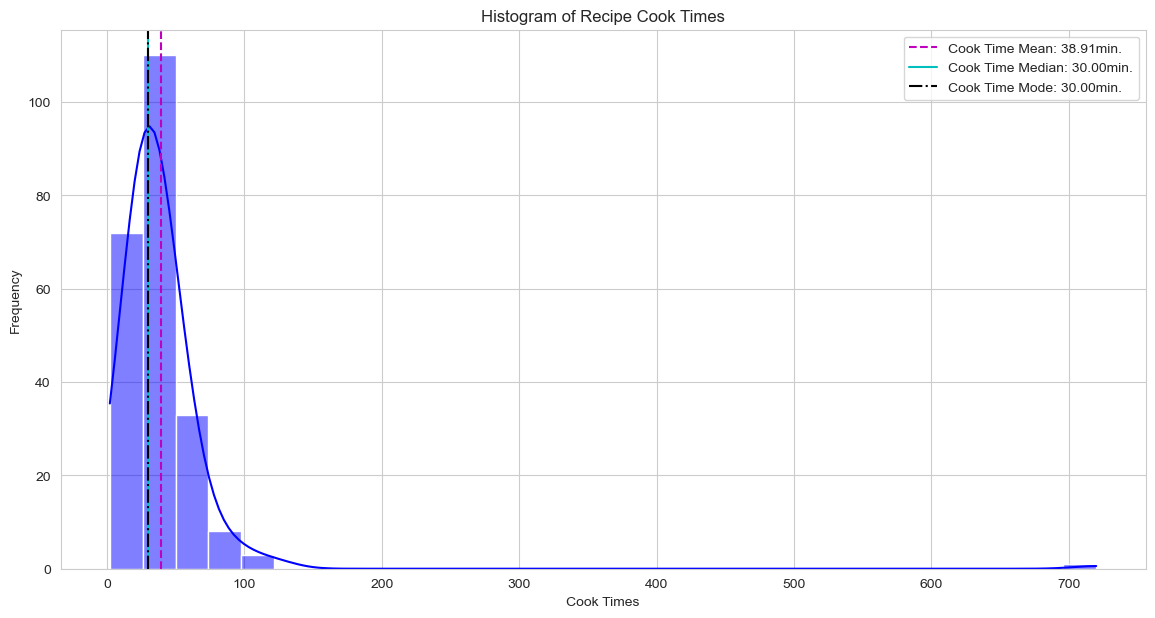

In [122]:
sns.set_style("whitegrid")

plt.figure(figsize=(14, 7))



sns.histplot(x=df['cook_time'], bins=30, kde=True, color="blue")

plt.axvline(mean_cooktime, color='m', linestyle='--', label=f"Cook Time Mean: {mean_cooktime:.2f}min.")
plt.axvline(median_cooktime, color='c', linestyle='-', label=f"Cook Time Median: {median_cooktime:.2f}min.")
plt.axvline(mode_cooktime, color='k', linestyle='-.', label=f"Cook Time Mode: {mode_cooktime:.2f}min.")

plt.annotate('Skewness: {:.2f}\nKurtosis: {:.2f}'.format(df['cook_time'].skew(), df['cook_time'].kurt()),
             xy=(1000, 100), fontsize=14, bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="aliceblue"))

plt.title('Histogram of Recipe Cook Times')
plt.xlabel('Cook Times')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Correlation: 0.11


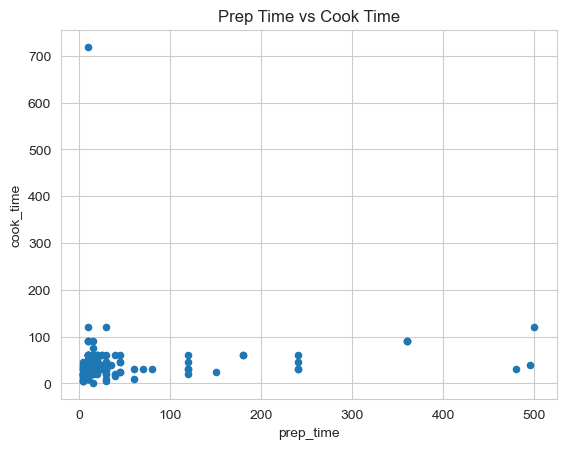

In [123]:
# 1. Calculate Correlation Coefficient
# Uses Pearson correlation by default, returns -1 to 1 [8]
correlation = df['prep_time'].corr(df['cook_time'])
print(f"Correlation: {correlation:.2f}")

# 2. Create Scatter Plot
df.plot.scatter(x='prep_time', y='cook_time', title='Prep Time vs Cook Time')
plt.show()

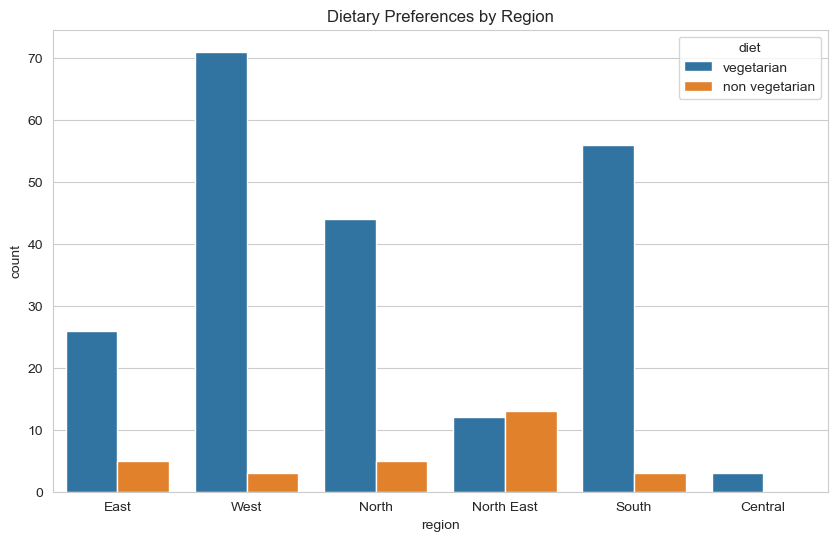

In [124]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='region', hue='diet')
plt.title('Dietary Preferences by Region')
plt.show()

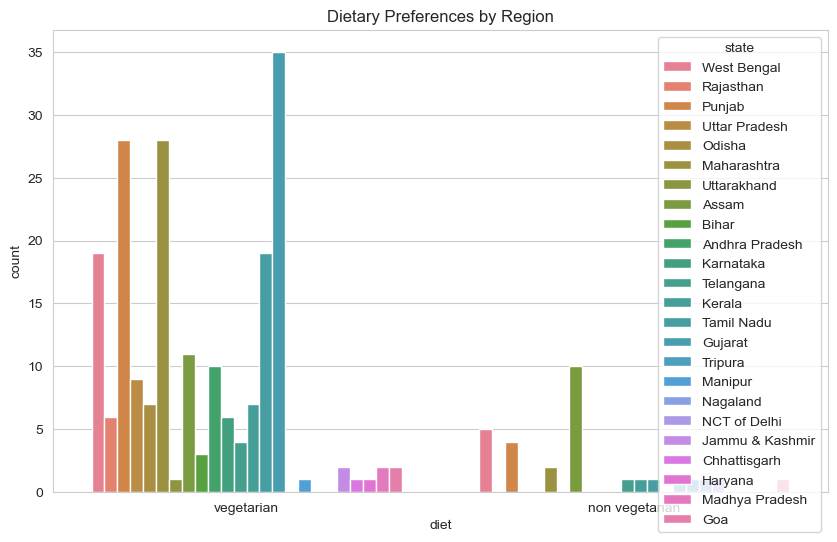

In [125]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='diet', hue='state')
plt.title('Dietary Preferences by Region')
plt.show()

In [126]:
# 5. Ingredient Processing
# =============================
df["ingredients_list"] = df["ingredients"].str.split(",")

# Clean ingredients

def clean_ingredients(lst):
    return [i.strip().lower() for i in lst if isinstance(i, str)]


df["ingredients_list"] = df["ingredients_list"].apply(clean_ingredients)

# Count ingredients
df["num_ingredients"] = df["ingredients_list"].apply(len)

print(df["ingredients_list"])
print(df["num_ingredients"])

0                      [maida flour, yogurt, oil, sugar]
1                              [gram flour, ghee, sugar]
2         [carrots, milk, sugar, ghee, cashews, raisins]
3      [flour, ghee, kewra, milk, clarified butter, s...
4      [milk powder, plain flour, baking powder, ghee...
                             ...                        
250            [glutinous rice, black sesame seeds, gur]
251    [coconut milk, egg yolks, clarified butter, al...
252    [cottage cheese, dry dates, dried rose petals,...
253    [milk powder, dry fruits, arrowroot powder, al...
254    [brown rice, fennel seeds, grated coconut, bla...
Name: ingredients_list, Length: 255, dtype: object
0       4
1       3
2       6
3      10
4       8
       ..
250     3
251     4
252     5
253     4
254     5
Name: num_ingredients, Length: 255, dtype: int64


In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Create Dummy Data (Replacing a Kaggle dataset)
#data = {
 #   'Region': ['Central', 'East', 'North', 'North East', 'South', 'West'] * 2,
  #  'Diet': ['Vegetarian']*6 + ['Non-Vegetarian']*6,
  #  'Count': [45, 60, 110, 50, 70, 95,  # Veg counts
   #           15, 25, 30, 40, 65, 40]   # Non-Veg counts
#}
#df = pd.DataFrame(data)

# 2. Pivot the data to get regions as index and diets as columns
df_pivot = df.pivot(index='region', columns='diet', values='count')

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

# Set position of bar on X axis
x = np.arange(len(df_pivot.index))
width = 0.35  # width of bars

# Make the plot
rects1 = ax.bar(x - width/2, df_pivot['Vegetarian'], width, label='Vegetarian', color='#4CAF50')
rects2 = ax.bar(x + width/2, df_pivot['Non-Vegetarian'], width, label='Non-Vegetarian', color='#F44336')

# 4. Add labels on top of bars (using bar_label for cleaner code)
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

# Add styling
ax.set_ylabel('Number of Recipes', fontsize=12)
ax.set_title('Vegetarian vs Non-Vegetarian Recipes by Region', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index)
ax.legend()
plt.tight_layout()

# Display
plt.show()

KeyError: 'count'